<a href="https://colab.research.google.com/github/Arrah28/AWS-ML-Financial-Health-Analytics-Project/blob/main/Supervised_Stroke_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#Supervised Data Summary

---







In [17]:
#Loads the datasets into Collab
stroke_df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
print ('Print Databases loaded successfully')

Print Databases loaded successfully


In [18]:
# STROKE DATASET SUMMARY
print("--- STROKE DATASET OVERVIEW ---")
print(f"Instances (Rows): {stroke_df.shape[0]}")
print(f"Features (Columns): {stroke_df.shape[1]}")
print("\nMissing Values per Feature:")
print(stroke_df.isnull().sum())

--- STROKE DATASET OVERVIEW ---
Instances (Rows): 5110
Features (Columns): 12

Missing Values per Feature:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [19]:
#Mean , Mediam and Standard deviations
print("--- STROKE NUMERICAL MEASURES ---")
stats_stroke = stroke_df[['age', 'avg_glucose_level', 'bmi']].agg(['mean', 'median', 'std'])
print(stats_stroke)

--- STROKE NUMERICAL MEASURES ---
              age  avg_glucose_level        bmi
mean    43.226614         106.147677  28.893237
median  45.000000          91.885000  28.100000
std     22.612647          45.283560   7.854067


In [20]:
# --- CATEGORICAL DISTRIBUTION (STROKE) ---
print("--- STROKE CATEGORICAL DATA ---")
print("Work Type Distribution:\n", stroke_df['work_type'].value_counts())
print("\nSmoking Status Distribution:\n", stroke_df['smoking_status'].value_counts())

--- STROKE CATEGORICAL DATA ---
Work Type Distribution:
 work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Smoking Status Distribution:
 smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


##Visualisations: Histogram, Boxplot and Scatter Plot

---

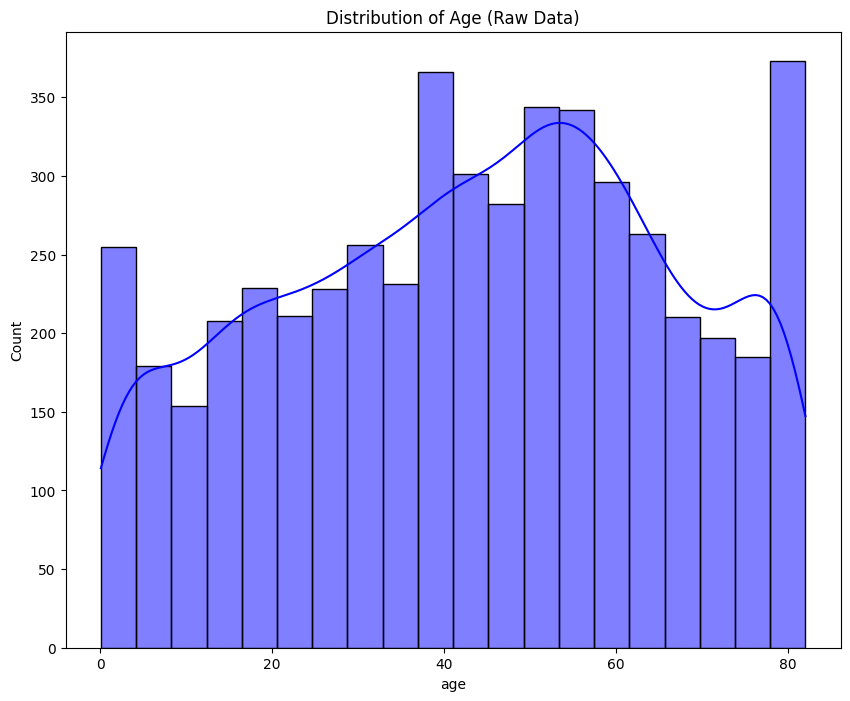

In [21]:
#Histogram is used to check for "Data Distribution" to see if we have a good mix of ages.
plt.figure(figsize=(10, 8))
sns.histplot(stroke_df['age'], kde=True, color='blue')
plt.title('Distribution of Age (Raw Data)')
plt.show()

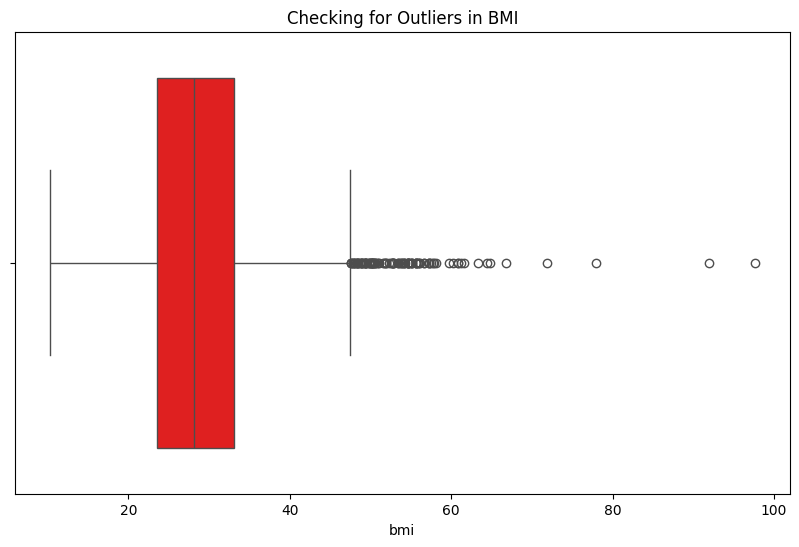

In [22]:
# A Boxplotto show the extreme BMI values which are the OUTLIERS that we will need later.
plt.figure(figsize=(10, 6))
sns.boxplot(x=stroke_df['bmi'], color='red')
plt.title('Checking for Outliers in BMI')
plt.show()

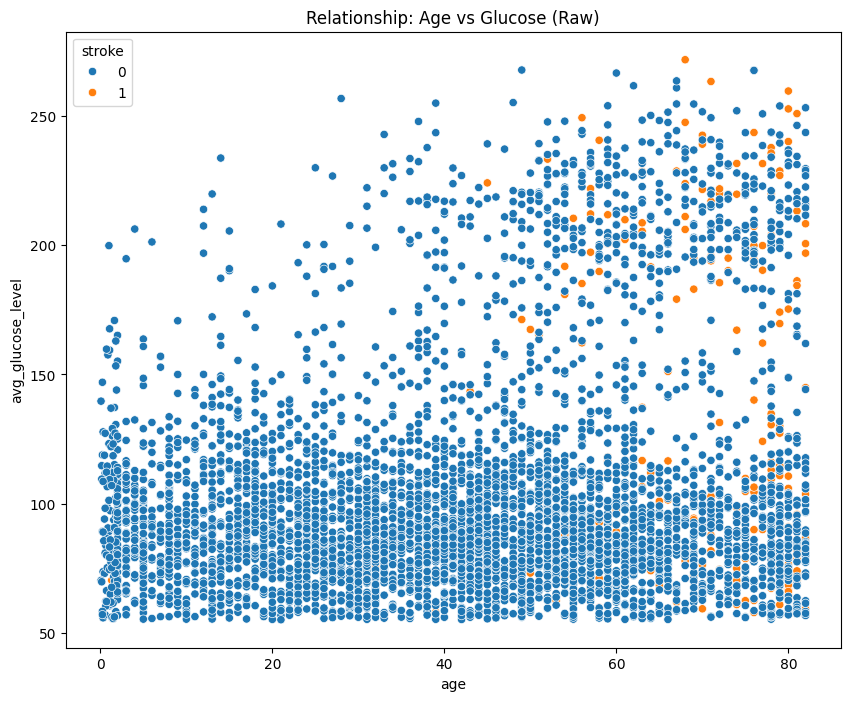

In [23]:
# 3. Scatter Plot: Check for "Relationships" between features , in this case Age and Glucose.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=stroke_df, x='age', y='avg_glucose_level', hue='stroke')
plt.title('Relationship: Age vs Glucose (Raw)')
plt.show()

#Data Pre-processing

---


In [24]:
#this will fill the  201 missing BMI values with the median
imputer = SimpleImputer(strategy='median')
stroke_df['bmi'] = imputer.fit_transform(stroke_df[['bmi']])

In [25]:
#Encode categorical features via one hot Encoding
stroke_df_encoded = pd.get_dummies(stroke_df, columns=['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status'])

In [26]:
#Standardise the numerical value so the all hav an average of 0 , making the data amore centered and comperable
scaler = StandardScaler()
stroke_df_encoded[['age', 'avg_glucose_level', 'bmi']] = scaler.fit_transform(
    stroke_df_encoded[['age', 'avg_glucose_level', 'bmi']]
)

In [27]:
#Removed the ID column, no vlaue of effect
stroke_df_final = stroke_df_encoded.drop('id', axis=1)

print("Stroke Pre-processing")
stroke_df_final.head()

Stroke Pre-processing


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1.051434,0,1,2.706375,1.005086,1,False,True,False,False,...,False,True,False,False,False,True,False,True,False,False
1,0.786070,0,0,2.121559,-0.098981,1,True,False,False,False,...,False,False,True,False,True,False,False,False,True,False
2,1.626390,0,1,-0.005028,0.472536,1,False,True,False,False,...,False,True,False,False,True,False,False,False,True,False
3,0.255342,0,0,1.437358,0.719327,1,True,False,False,False,...,False,True,False,False,False,True,False,False,False,True
4,1.582163,1,0,1.501184,-0.631531,1,True,False,False,False,...,False,False,True,False,True,False,False,False,True,False


#Test and Train Code Division

---



In [28]:
# Separate the features (X - stroke ) from the target (y - which is what we want to predict,stroke)
X = stroke_df_final.drop('stroke', axis=1)
y = stroke_df_final['stroke']

#We will use 80% for training and 20% for testing (0.2)
# stratify=y ensures both sets have the same percentage of strokes.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")

Training set size: 4088 rows
Testing set size: 1022 rows
